In [3]:
import os
import re
import json
import random
import tarfile
import logging
import requests
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path
from typing import Optional
from tqdm import tqdm


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from transformers import AutoProcessor, AutoModelForCausalLM


In [4]:
# 1. 디바이스 설정 및 모델 로드
# ResNet50 기반 Encoder + Transformer Decoder로 구성된 대표적인 Pre-trained 이미지 캡셔닝 모델
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'data')
data_path = os.path.join(base_path, 'StanfordDogs')

In [ ]:
def download_and_extract_stanford_dogs():
    """
    Stanford Dogs 데이터셋을 다운로드하고 압축을 푸는 파이썬 코드입니다.
    """

    # 1. 파일 URL 및 저장할 디렉토리 설정
    url_base = "http://vision.stanford.edu/aditya86/ImageNetDogs/"
    urls = {
        "images": url_base + "images.tar",
        "annotations": url_base + "annotation.tar",
        "lists": url_base + "lists.tar"
    }
    
    # 데이터를 저장할 폴더 (현재 디렉토리 아래 'data' 폴더)
    data_dir = data_path
    
    # 데이터를 저장할 디렉토리가 없으면 생성
    os.makedirs(data_dir, exist_ok=True)
    
    print("Stanford Dogs 데이터셋 다운로드를 시작합니다.")
    print("--------------------------------------------------")

    for file_key, url in urls.items():
        # 파일 이름 추출 (예: 'images.tar')
        filename = url.split('/')[-1]
        filepath = os.path.join(data_dir, filename)

        # 2. 파일 다운로드
        if not os.path.exists(filepath):
            print(f"{filename} 다운로드 중...")
            
            # chunk_size를 설정하여 메모리를 효율적으로 사용
            response = requests.get(url, stream=True)
            response.raise_for_status() # 오류 발생 시 예외 처리
            
            # 파일 쓰기
            with open(filepath, 'wb') as f:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)
            print(f"{filename} 다운로드 완료.")
        else:
            print(f"{filename}이(가) 이미 존재합니다. 다운로드를 건너뜁니다.")

        # 3. 압축 풀기
        # .tar 파일의 경우
        if filename.endswith(".tar"):
            # 압축을 풀 디렉토리 경로 (예: './data/StanfordDogs/Images')
            # 팁: '.tar'를 떼어내고 파일 종류 이름을 대문자로 시작하게 만듭니다.
            extract_folder = file_key.capitalize() 
            extract_path = os.path.join(data_dir, extract_folder)
            
            # 압축을 푼 디렉토리가 없으면 압축을 풉니다.
            if not os.path.exists(extract_path):
                print(f"{filename} 압축 푸는 중 ({extract_path}에)...")
                try:
                    with tarfile.open(filepath, 'r') as tar:
                        tar.extractall(path=data_dir) # DATA_DIR에 직접 풉니다. (구조 유지)
                    print(f"{filename} 압축 해제 완료.")
                except tarfile.TarError as e:
                    print(f"{filename} 압축 해제 중 오류 발생: {e}")
            else:
                print(f"{filename}이(가) 이미 압축 해제되었습니다. 건너뜁니다.")
        
        print("--------------------------------------------------")

    print("\nStanford Dogs 데이터셋 준비가 완료되었습니다.")
    print(f"데이터는 '{data_dir}' 폴더에 저장되어 있습니다.")


download_and_extract_stanford_dogs()

Stanford Dogs 데이터셋 다운로드를 시작합니다.
--------------------------------------------------
images.tar이(가) 이미 존재합니다. 다운로드를 건너뷉니다.
images.tar이(가) 이미 압축 해제되었습니다. 건너뷉니다.
--------------------------------------------------
annotation.tar 다운로드 중...
annotation.tar 다운로드 완료.
annotation.tar 압축 푸는 중 (/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/CAM/../../work/data/StanfordDogs/Annotations에)...
annotation.tar 압축 해제 완료.
--------------------------------------------------
lists.tar 다운로드 중...
lists.tar 다운로드 완료.
lists.tar 압축 푸는 중 (/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/CAM/../../work/data/StanfordDogs/Lists에)...
lists.tar 압축 해제 완료.
--------------------------------------------------

Stanford Dogs 데이터셋 준비가 완료되었습니다.
데이터는 '/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/CAM/../../work/data/StanfordDogs' 폴더에 저장되어 있습니다.


In [16]:
# 2. Grad-CAM을 위한 그라디언트 훅(Hook) 설정
# 비전 엔코더의 최종 특징 추출 레이어(레이어 정규화 직전 또는 직후) 지정
activation = None
gradient = None

def forward_hook(module, input, output):
    global activation
    # 출력 형태: [Batch, Sequence_Length, Hidden_Dimension]
    activation = output

def backward_hook(module, grad_in, grad_out):
    global gradient
    gradient = grad_out[0]

In [17]:
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

# for name, module in model.git.image_encoder.named_modules():
#     if name: # 하위 모듈 이름들 확인
#         print(name)

# microsoft/git-base의 비전 엔코더 마지막 레이어 레이어 타겟팅
target_module = model.git.image_encoder.vision_model.encoder.layers[-1]
target_module.register_forward_hook(forward_hook)
target_module.register_backward_hook(backward_hook)

2026-06-25 15:05:39,374 [INFO] HTTP Request: HEAD https://huggingface.co/microsoft/git-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-06-25 15:05:39,577 [INFO] HTTP Request: HEAD https://huggingface.co/microsoft/git-base/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-25 15:05:39,587 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/git-base/1f7fe8444292beb4a259e3a5b6eba440cd5999d4/preprocessor_config.json "HTTP/1.1 200 OK"
2026-06-25 15:05:39,794 [INFO] HTTP Request: HEAD https://huggingface.co/microsoft/git-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-06-25 15:05:40,024 [INFO] HTTP Request: HEAD https://huggingface.co/microsoft/git-base/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-25 15:05:40,033 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/git-base/1f7fe8444292beb4a259e3a5b6eba440cd5999d4/preproces

Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]

2026-06-25 15:05:44,090 [INFO] HTTP Request: HEAD https://huggingface.co/microsoft/git-base/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-25 15:05:44,100 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/git-base/1f7fe8444292beb4a259e3a5b6eba440cd5999d4/generation_config.json "HTTP/1.1 200 OK"


▶ 모델이 생성한 전체 캡션 문장: "a dog with a ball in his mouth"
▶ Grad-CAM 분석 대상 단어: 'dog' (Index: 2)


/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/torch/nn/modules/module.py:1842: FutureWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


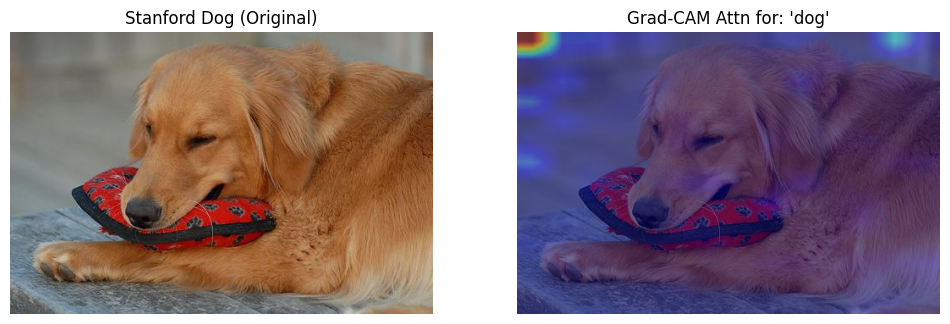

In [18]:

# 3. Stanford Dogs 데이터셋 샘플 이미지 세팅 (골든 리트리버)
img_path = os.path.join(data_path, "Images", "n02099601-golden_retriever", "n02099601_10.jpg")
image = Image.open(img_path).convert("RGB")


# 모델 전용 프로세서로 입력 텐서 생성
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

# 4. 문장 생성 (추론)
model.eval()
with torch.no_grad():
    generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(f"▶ 모델이 생성한 전체 캡션 문장: \"{generated_caption}\"")

# 5. 특정 단어 타겟팅하여 그라디언트 역전파 (Backward Pass)
# 캡션 문장에서 중요한 단어를 선택해 그라디언트를 추적합니다.
# 생성된 토큰들을 다시 포워드하여 연산 그래프를 생성합니다.
input_ids = generated_ids.to(device)
outputs = model(pixel_values=pixel_values, input_ids=input_ids)
logits = outputs.logits # [1, seq_len, vocab_size]

# 예시: 문장의 마지막 단어 혹은 핵심 타겟 단어 지정 (여기선 첫 단어 다음 토큰 타겟팅)
target_idx = 2 # 문장 내 토큰 위치 인덱스 조정 가능
target_token_id = input_ids[0, target_idx].item()
target_word = processor.tokenizer.decode([target_token_id])

print(f"▶ Grad-CAM 분석 대상 단어: '{target_word.strip()}' (Index: {target_idx})")

# 해당 토큰 점수로 백워드 수행
model.zero_grad()
score = logits[0, target_idx - 1, target_token_id] # 이전 시점 기반 예측 스코어
score.backward()

# 6. Grad-CAM 히트맵 연산
# 특징 맵 차원에 맞춰 그라디언트 평균(GAP) 계산
grads = gradient.cpu().data.numpy()[0] # [Seq_len, Hidden_dim]
acts = activation.cpu().data.numpy()[0]   # [Seq_len, Hidden_dim]

# 이미지 피처 시퀀스(보통 grid 형태, git-base의 경우 197개 패치 토큰)에 대해 채널 가중치 연산
# 클래스 토큰 제외한 스페셜 공간 차원 매핑을 위해 리사이즈 준비
weights = np.mean(grads, axis=1) # 각 위치별 중요도 가중치
cam = np.zeros(acts.shape[0], dtype=np.float32)

for i, w in enumerate(weights):
    cam[i] = w * np.mean(acts[i, :])

# 1D 시퀀스 데이터를 2D 이미지 그리드(예: 14x14) 형태로 변환
# GIT-base 비전 패치 크기 기준(197개 중 첫 번째는 cls 토큰이므로 제외 후 14x14 리사이즈)
cam = cam[1:] 
grid_size = int(np.sqrt(len(cam)))
cam = cam.reshape(grid_size, grid_size)

# ReLU 적용 및 정규화
cam = np.maximum(cam, 0)
cam = cam - np.min(cam)
cam = cam / (np.max(cam) + 1e-8)

# 원본 이미지 비율로 확대
cam_resized = np.array(Image.fromarray(cam).resize(image.size, Image.BILINEAR))

# 7. 시각화 출력
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Stanford Dog (Original)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image)
plt.imshow(cam_resized, cmap='jet', alpha=0.45)
plt.title(f"Grad-CAM Attn for: '{target_word.strip()}'")
plt.axis('off')

plt.show()

사용 디바이스: cuda


Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]


▶ 생성된 캡션: "a dog with a ball in his mouth"
▶ Grad-CAM 타겟 단어: 'dog' (시퀀스 인덱스: 2)

▶ Activation shape : (197, 768)
▶ Gradient shape   : (197, 768)
▶ Gradient 절댓값 평균: 0.001886
▶ Gradient 최대값    : 0.704929

▶ 내적 CAM 범위 (ReLU 전): [-0.000245, 0.000004]
▶ 내적 CAM 범위 (ReLU 후): [0.000000, 0.000004]


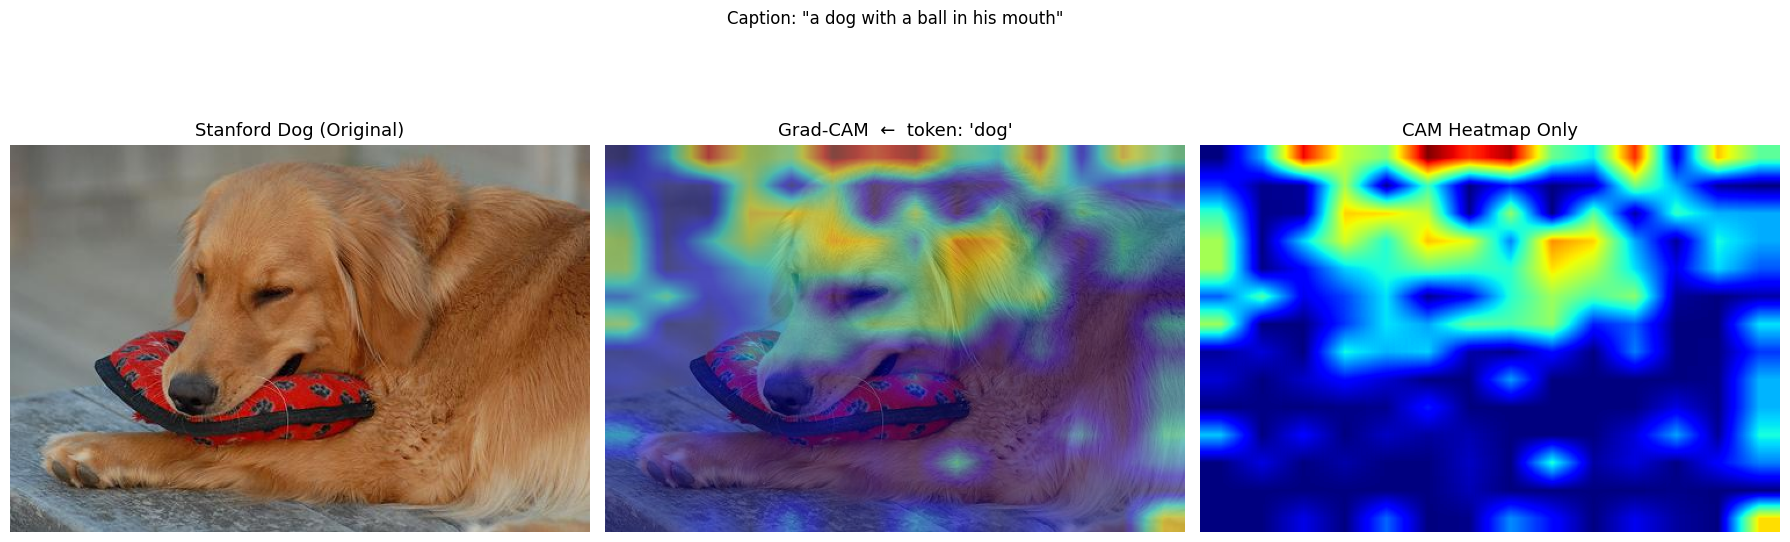


결과 저장: gradcam_result_fixed.png


In [5]:
"""
GIT-base Image Captioning + Grad-CAM (수정 버전 v2)
====================================================
수정 이력:
  v1 - activation tuple 처리, target_idx 자동탐색, detach() 추가
  v2 - [핵심] register_backward_hook → register_full_backward_hook 교체
         tuple 입력 모듈에서 grad 일부 누락 → CAM 전부 0 문제 해결
       - 그래디언트 흐름 수치 검증 로직 추가
"""

import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForCausalLM

# ──────────────────────────────────────────────
# 1. 디바이스 설정 및 경로
# ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'data')
data_path = os.path.join(base_path, 'StanfordDogs')

# ──────────────────────────────────────────────
# 2. Hook 설정
# ──────────────────────────────────────────────
activation = {}
gradient = {}

def forward_hook(module, input, output):
    """
    Vision Encoder 레이어 출력은 tuple(hidden_state, ...) 형태.
    output[0]으로 hidden_state만 명시적으로 추출.
    """
    if isinstance(output, tuple):
        activation["value"] = output[0]  # (batch, seq_len, hidden_dim)
    else:
        activation["value"] = output

def full_backward_hook(module, grad_input, grad_output):
    """
    [v2 핵심 수정] register_full_backward_hook 사용.

    기존 register_backward_hook의 문제:
      - 모듈 입력이 (hidden_state, attention_mask, ...) 같은 tuple일 때
        grad를 일부만 캡처하거나 완전히 누락함 (FutureWarning 경고 발생)
      - 결과: gradient["value"]가 0 텐서 또는 미채워진 상태
        → CAM 전체가 0 → 파란 히트맵

    register_full_backward_hook:
      - 입력/출력 형태와 무관하게 grad_output[0]을 정확히 전달
      - grad_output[0]: 이 레이어 출력 텐서에 대한 그래디언트
                        shape = (batch, seq_len, hidden_dim)
    """
    if grad_output[0] is not None:
        gradient["value"] = grad_output[0]  # (batch, seq_len, hidden_dim)

# ──────────────────────────────────────────────
# 3. 모델 / 프로세서 로드
# ──────────────────────────────────────────────
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

target_module = model.git.image_encoder.vision_model.encoder.layers[-1]
target_module.register_forward_hook(forward_hook)
target_module.register_full_backward_hook(full_backward_hook)  # ← v2 수정

# ──────────────────────────────────────────────
# 4. 이미지 로드
# ──────────────────────────────────────────────
img_path = os.path.join(
    data_path, "Images",
    "n02099601-golden_retriever", "n02099601_10.jpg"
)
image = Image.open(img_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

# ──────────────────────────────────────────────
# 5. 캡션 생성 (토큰 시퀀스 확보 전용)
# ──────────────────────────────────────────────
model.eval()

with torch.no_grad():
    generated_ids = model.generate(pixel_values=pixel_values, max_length=50)

generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(f"\n▶ 생성된 캡션: \"{generated_caption}\"")

# ──────────────────────────────────────────────
# 6. 타겟 토큰 자동 선택 (불용어 제외)
# ──────────────────────────────────────────────
STOPWORDS = {
    "a", "an", "the", "is", "are", "was", "were",
    "of", "in", "on", "at", "to", "and", "or", "with",
    "it", "its", "this", "that", "there", "i", ".", ",", ""
}

def find_target_token(generated_ids, processor, stopwords=STOPWORDS):
    """불용어가 아닌 첫 번째 실질 토큰의 (인덱스, 단어)를 반환."""
    tokens = generated_ids[0]
    for idx in range(1, len(tokens)):
        word = processor.tokenizer.decode([tokens[idx].item()]).strip().lower()
        if word not in stopwords and len(word) > 1:
            return idx, word
    fallback_word = processor.tokenizer.decode([tokens[2].item()]).strip()
    return 2, fallback_word

target_idx, target_word = find_target_token(generated_ids, processor)
target_token_id = generated_ids[0, target_idx].item()
print(f"▶ Grad-CAM 타겟 단어: '{target_word}' (시퀀스 인덱스: {target_idx})")

# ──────────────────────────────────────────────
# 7. Grad-CAM 포워드 — 그래프 유지 (no_grad 없음)
# ──────────────────────────────────────────────
input_ids = generated_ids.to(device)

model.zero_grad()
outputs = model(pixel_values=pixel_values, input_ids=input_ids)
logits = outputs.logits  # (1, seq_len, vocab_size)

# ──────────────────────────────────────────────
# 8. 스코어 정의 및 역전파
# ──────────────────────────────────────────────
score = logits[0, target_idx - 1, target_token_id]
score.backward()

# ──────────────────────────────────────────────
# 9. 그래디언트 흐름 검증 (v2 추가)
# ──────────────────────────────────────────────
if "value" not in gradient:
    raise RuntimeError("gradient가 캡처되지 않았습니다. hook 등록을 확인하세요.")

grads = gradient["value"].detach().cpu().numpy()[0]  # (seq_len, hidden_dim)
acts  = activation["value"].detach().cpu().numpy()[0] # (seq_len, hidden_dim)

print(f"\n▶ Activation shape : {acts.shape}")
print(f"▶ Gradient shape   : {grads.shape}")
print(f"▶ Gradient 절댓값 평균: {np.abs(grads).mean():.6f}")
print(f"▶ Gradient 최대값    : {np.abs(grads).max():.6f}")

if np.abs(grads).max() < 1e-8:
    raise RuntimeError(
        "그래디언트가 모두 0입니다.\n"
        "원인: Vision Encoder 출력이 역전파 경로에서 분리되었을 가능성.\n"
        "pixel_values.requires_grad 또는 모델 freeze 여부를 확인하세요."
    )

# ──────────────────────────────────────────────
# 10. Grad-CAM 히트맵 연산
# ──────────────────────────────────────────────
"""
기존 방식의 문제:
  cam[i] = mean(grads[i]) * mean(acts[i])
  → Transformer LayerNorm으로 인해 acts의 평균이 0 근방에 분포
  → 곱이 전부 음수가 되어 ReLU 후 전부 0

교체 방식 — Gradient · Activation 내적 (per-patch):
  cam[i] = sum(grads[i] * acts[i])   (hidden_dim 방향 내적)
  = 각 패치 위치에서 그래디언트와 activation이 같은 방향으로
    정렬된 정도를 측정 → 양수값이 자연스럽게 유지됨

이 방식이 Transformer hidden state에 적합한 이유:
  - LayerNorm 이후에도 채널별 부호가 살아있어 내적이 의미를 가짐
  - CNN Grad-CAM의 GAP(Global Average Pooling) 가중합과
    수학적으로 동등하지만 Transformer 구조에서 더 안정적
"""

# 패치별 그래디언트-활성화 내적: (seq_len, hidden_dim) → (seq_len,)
cam = np.sum(grads * acts, axis=1).astype(np.float32)

# CLS 토큰 제외 → 196개 패치 토큰
cam = cam[1:]
grid_size = int(np.sqrt(len(cam)))  # 14
cam = cam[: grid_size * grid_size].reshape(grid_size, grid_size)

print(f"\n▶ 내적 CAM 범위 (ReLU 전): [{cam.min():.6f}, {cam.max():.6f}]")

# ReLU → 양수 기여 영역만 강조
cam = np.maximum(cam, 0)
print(f"▶ 내적 CAM 범위 (ReLU 후): [{cam.min():.6f}, {cam.max():.6f}]")

if cam.max() > 1e-8:
    cam = (cam - cam.min()) / (cam.max() - cam.min())
else:
    print("⚠️  ReLU 후에도 전부 0 — ReLU 제거 후 전체 범위로 정규화합니다.")
    cam = np.sum(grads * acts, axis=1).astype(np.float32)[1: grid_size * grid_size + 1]
    cam = cam.reshape(grid_size, grid_size)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# 원본 이미지 크기로 업샘플
cam_resized = np.array(
    Image.fromarray((cam * 255).astype(np.uint8)).resize(image.size, Image.BILINEAR)
) / 255.0

# ──────────────────────────────────────────────
# 11. 시각화
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Stanford Dog (Original)", fontsize=13)
axes[0].axis("off")

axes[1].imshow(image)
axes[1].imshow(cam_resized, cmap="jet", alpha=0.45)
axes[1].set_title(f"Grad-CAM  ←  token: '{target_word}'", fontsize=13)
axes[1].axis("off")

axes[2].imshow(cam_resized, cmap="jet")
axes[2].set_title("CAM Heatmap Only", fontsize=13)
axes[2].axis("off")

plt.suptitle(f'Caption: "{generated_caption}"', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("gradcam_result_fixed.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n결과 저장: gradcam_result_fixed.png")

# ──────────────────────────────────────────────
# 12. 여러 토큰 비교 시각화 함수
# ──────────────────────────────────────────────
def gradcam_for_token(model, pixel_values, input_ids, target_idx,
                      activation, gradient, word_label=""):
    """단일 토큰에 대한 Grad-CAM 히트맵(numpy 2D) 반환."""
    model.zero_grad()
    outputs = model(pixel_values=pixel_values, input_ids=input_ids)
    logits = outputs.logits

    target_token_id = input_ids[0, target_idx].item()
    score = logits[0, target_idx - 1, target_token_id]
    score.backward()

    grads = gradient["value"].detach().cpu().numpy()[0]
    acts  = activation["value"].detach().cpu().numpy()[0]

    # 그래디언트 흐름 검증
    grad_mean = np.abs(grads).mean()
    grad_max  = np.abs(grads).max()
    label_str = f"'{word_label}' " if word_label else ""
    print(f"  [{label_str}idx={target_idx}] "
          f"grad 절댓값 평균: {grad_mean:.6f} | 최대: {grad_max:.6f}")

    if grad_max < 1e-8:
        print(f"  ⚠️  [{label_str}] 그래디언트가 0 — 이 토큰의 CAM은 유효하지 않습니다.")

    # 패치별 그래디언트-활성화 내적
    cam = np.sum(grads * acts, axis=1).astype(np.float32)
    cam = cam[1:]
    gs = int(np.sqrt(len(cam)))
    cam = cam[:gs * gs].reshape(gs, gs)
    cam = np.maximum(cam, 0)
    if cam.max() > 1e-8:
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    else:
        cam = np.sum(grads * acts, axis=1).astype(np.float32)[1: gs * gs + 1]
        cam = cam.reshape(gs, gs)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam


def visualize_all_tokens(model, processor, image, pixel_values,
                         generated_ids, activation, gradient,
                         stopwords=STOPWORDS):
    """의미 있는 모든 토큰에 대해 Grad-CAM 히트맵을 한번에 시각화."""
    tokens = generated_ids[0]
    targets = [
        (idx, processor.tokenizer.decode([tokens[idx].item()]).strip())
        for idx in range(1, len(tokens))
        if processor.tokenizer.decode([tokens[idx].item()]).strip().lower()
           not in stopwords
        and len(processor.tokenizer.decode([tokens[idx].item()]).strip()) > 1
    ]

    if not targets:
        print("시각화할 의미 있는 토큰이 없습니다.")
        return

    n = len(targets)
    fig, axes = plt.subplots(1, n + 1, figsize=(5 * (n + 1), 5))
    axes[0].imshow(image)
    axes[0].set_title("Original", fontsize=11)
    axes[0].axis("off")

    input_ids = generated_ids.to(device)
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    for col, (idx, word) in enumerate(targets, start=1):
        cam = gradcam_for_token(model, pixel_values, input_ids,
                                idx, activation, gradient,
                                word_label=word)  # ← word_label 전달
        cam_resized = np.array(
            Image.fromarray((cam * 255).astype(np.uint8)).resize(image.size, Image.BILINEAR)
        ) / 255.0
        axes[col].imshow(image)
        axes[col].imshow(cam_resized, cmap="jet", alpha=0.45)
        axes[col].set_title(f"'{word}'\n(idx={idx})", fontsize=10)
        axes[col].axis("off")

    plt.suptitle(f'Caption: "{caption}"', fontsize=12)
    plt.tight_layout()
    plt.savefig("gradcam_all_tokens.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("전체 토큰 비교 저장: gradcam_all_tokens.png")


# 전체 토큰 비교 실행 (주석 해제 시 사용)
# visualize_all_tokens(model, processor, image, pixel_values,
#                      generated_ids, activation, gradient)

  ['dog' idx=2] grad 절댓값 평균: 0.001886 | 최대: 0.704929
  ['ball' idx=5] grad 절댓값 평균: 0.001341 | 최대: 0.609074
  ['his' idx=7] grad 절댓값 평균: 0.001318 | 최대: 0.491796
  ['mouth' idx=8] grad 절댓값 평균: 0.001387 | 최대: 0.540555
  ['[SEP]' idx=9] grad 절댓값 평균: 0.001723 | 최대: 0.466380


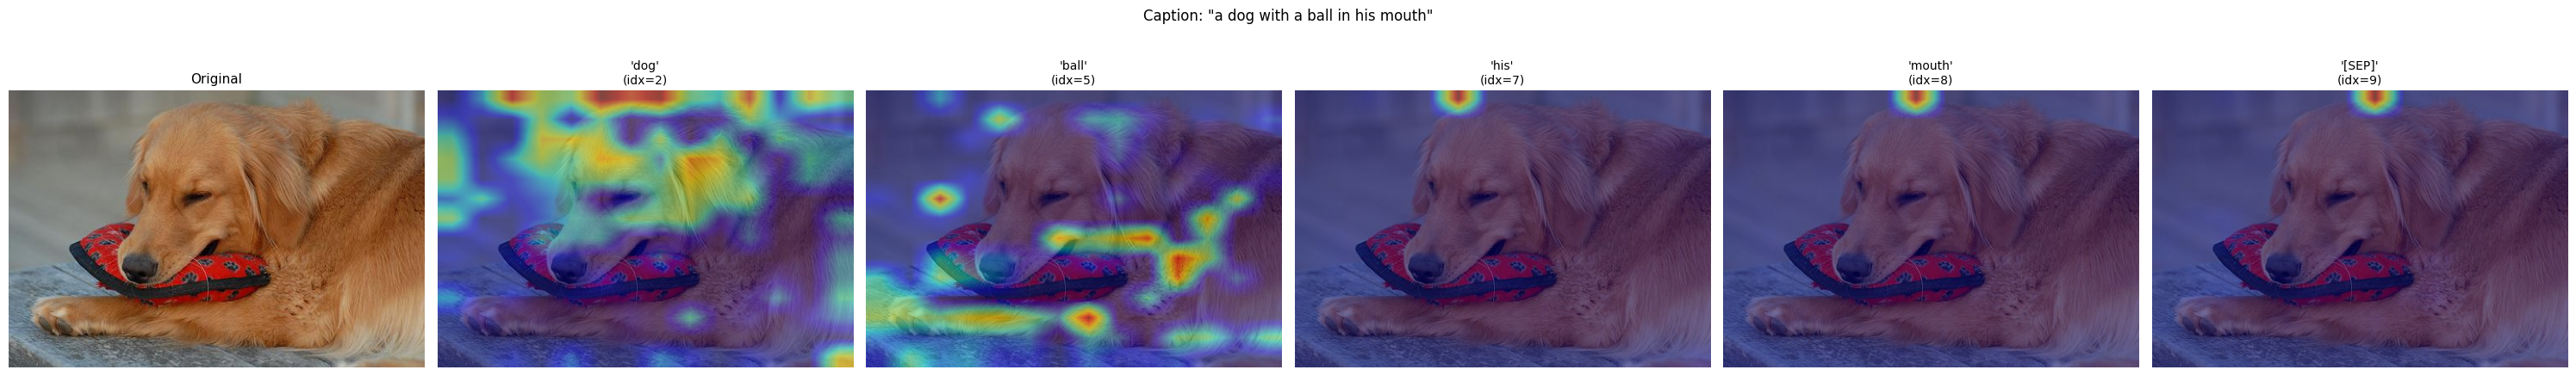

전체 토큰 비교 저장: gradcam_all_tokens.png


In [6]:
visualize_all_tokens(model, processor, image, pixel_values, generated_ids, activation, gradient)